In [160]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa as ls

## Load data

In [161]:
emotion_label = {
    "neutral":  0,
    "happy":    1,
    "sad":      2,
    "angry":    3,
    "fearful":  4,
    "disgust":  5,
    "surprised": 6,
}

ravdess_emotion = {
    "01": "neutral",
    "02": None,   # calm → None
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

example:

03-01-01-01-01-01-01.wav


Modality - VocalChannel - Emotion - Intensity - Statement - Repetition - Actor .wav

In [162]:
def load_ravdess_files(ravdess_root):

    records = []
    pattern_ = os.path.join(ravdess_root,'Actor_*','*.wav')
    files = glob.glob(pattern_)
    
    if not files:
        print(f"No .wav files found under {ravdess_root}. Check your folder path.")
    
    for file in files:
        fname = os.path.basename(file)
        parts = fname.replace(".wav","").split('-')
        if parts[0] != '03' or parts[1] != '01':
            continue
        emotion = ravdess_emotion[parts[2]]
        
        if emotion is None:
            continue

        gender = "female" if int(parts[6])%2==0 else "male"

        records.append({
            "path" : file,
            "emotion" : emotion,
            "label" : emotion_label[emotion],
            "actor" : parts[6],
            "gender" : gender,
            "dataset" : "ravdess"
        })

    df = pd.DataFrame(records)

    print(f"{len(df)} files are loaded")

    return df

In [163]:
df_ravdess = load_ravdess_files('dataset/RAVDESS') #use for training

1248 files are loaded


In [164]:
tess_folder_map = {
    "angry":              "angry",
    "disgust":            "disgust",
    "fear":               "fearful",
    "happy":              "happy",
    "neutral":            "neutral",  
    "ps":                 "surprised",  
    "sad":                "sad",
}

In [ ]:
def load_tess_files(tess_root):
    records = []
    
    for folder in os.listdir(tess_root):
        folder_path = os.path.join(tess_root, folder)
        if not os.path.isdir(folder_path):
            continue
        parts = folder.lower().split('_')
        if len(parts) < 2:
            continue
        emotion_key = '_'.join(parts[1:])
        emotion = tess_folder_map.get(emotion_key)
        if emotion is None:
            continue
        for file in glob.glob(os.path.join(folder_path, '*.wav')):
            records.append({
                "path":    file,
                "emotion": emotion,
                "label":   emotion_label[emotion],
                "actor":   parts[0],
                "gender":  "female",
                "dataset": "tess"
            })
    
    df = pd.DataFrame(records)
    print(f"{len(df)} files loaded")
    return df

In [166]:
df_tess = load_tess_files('dataset/TESS')

2800 files are loaded


In [167]:
print(df_tess['emotion'].value_counts())

angry        400
disgust      400
fearful      400
happy        400
neutral      400
surprised    400
sad          400
Name: emotion, dtype: int64


## Signal Proccesing & Mel Spectrogram Extraction

In [168]:
from PIL import Image

sr = 22050
duration = 3
n_mel = 128
img_heigth = 128
img_width = 128

def extract_from_path(path):

    y,_ = ls.load(path,sr=sr,duration=duration)
    
    #PADDING to fix length

    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    S = ls.feature.melspectrogram(y=y,sr=sr,n_mels=n_mel)
    S_db = ls.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-6)

    # Resize to fixed image size
    img = Image.fromarray((S_norm * 255).astype(np.uint8))
    img = img.resize((img_width, img_heigth), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0

    return np.expand_dims(arr, axis=-1)

## Making Datasets for Training and Testing

In [169]:
def augment(y):
    choice = np.random.randint(0, 2)
    if choice == 0:
        y = ls.effects.time_stretch(y, rate=np.random.uniform(0.85, 1.15))
    else:
        y = y + 0.005 * np.random.randn(len(y))
    return y


def make_dataset(df, augment_data=False):
    X = []
    y = []

    for i, row in df.iterrows():
        # Original sample
        X.append(extract_from_path(row['path']))
        y.append(row['label'])

        # Augmented copies (only for training data)
        if augment_data:
            audio, _ = ls.load(row['path'], sr=sr, duration=duration)
            for _ in range(3):   # 3 augmented copies per file
                
                audio_aug = augment(audio.copy())
                # pad or truncate
                
                target_len = int(sr * duration)
                
                if len(audio_aug) < target_len:
                    audio_aug = np.pad(audio_aug, (0, target_len - len(audio_aug)))
                else:
                    audio_aug = audio_aug[:target_len]
                
                # extract spectrogram
                S    = ls.feature.melspectrogram(y=audio_aug, sr=sr, n_mels=n_mel)
                S_db = ls.power_to_db(S, ref=np.max)
                S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-6)
                
                img  = Image.fromarray((S_norm * 255).astype(np.uint8))
                img  = img.resize((img_width, img_heigth), Image.BILINEAR)
                arr  = np.array(img, dtype=np.float32) / 255.0
                
                X.append(np.expand_dims(arr, axis=-1))
                y.append(row['label'])


    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X_ravdess, y_ravdess = make_dataset(df_ravdess,augment_data=True)

X_tess, y_tess = make_dataset(df_tess)

In [170]:
print(X_ravdess.shape, X_tess.shape)
print(y_ravdess.shape, y_tess.shape)

(4992, 128, 128, 1) (2800, 128, 128, 1)
(4992,) (2800,)


## Train CNN Model

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_ravdess, y_ravdess, test_size=0.15,random_state=42,stratify=y_ravdess)

In [172]:
X_train.shape

(4243, 128, 128, 1)

In [173]:
y_train.shape

(4243,)

In [174]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout, MaxPooling2D, Flatten, Conv2D, GlobalAveragePooling2D

In [175]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

In [176]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 128, 128, 32)      320       
                                                                 
 batch_normalization_27 (Bat  (None, 128, 128, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_27 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 dropout_35 (Dropout)        (None, 64, 64, 32)        0         
                                                                 
 conv2d_28 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_28 (Bat  (None, 64, 64, 64)      

In [177]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [178]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes.tolist(), weights.tolist()))
print(class_weight)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    class_weight=class_weight
)

{0: 1.859333917616126, 1: 0.9282432728068256, 2: 0.9282432728068256, 3: 0.9282432728068256, 4: 0.929666958808063, 5: 0.9282432728068256, 6: 0.9282432728068256}
Epoch 1/100
266/266 [==============================] - 6s 20ms/step - loss: 1.9381 - accuracy: 0.2081 - val_loss: 2.8006 - val_accuracy: 0.1615
Epoch 2/100
266/266 [==============================] - 5s 20ms/step - loss: 1.7890 - accuracy: 0.2668 - val_loss: 2.9081 - val_accuracy: 0.1535
Epoch 3/100
266/266 [==============================] - 5s 21ms/step - loss: 1.7189 - accuracy: 0.2934 - val_loss: 1.7809 - val_accuracy: 0.2710
Epoch 4/100
266/266 [==============================] - 6s 21ms/step - loss: 1.6222 - accuracy: 0.3446 - val_loss: 1.6064 - val_accuracy: 0.3698
Epoch 5/100
266/266 [==============================] - 6s 21ms/step - loss: 1.5366 - accuracy: 0.3896 - val_loss: 1.8994 - val_accuracy: 0.3204
Epoch 6/100
266/266 [==============================] - 5s 21ms/step - loss: 1.4575 - accuracy: 0.4165 - val_loss: 1.4476

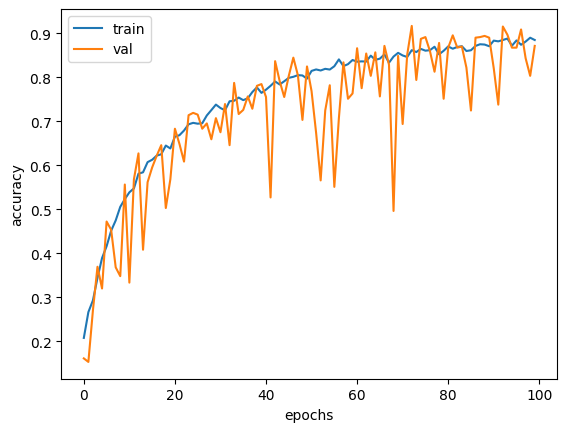

In [179]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

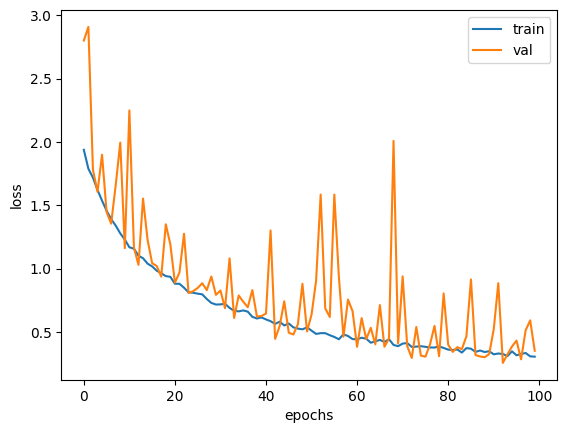

In [180]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='val')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [184]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_prob = model.predict(X_test)
y_pred_test = np.argmax(y_pred_prob,axis=1)
print(accuracy_score(y_test,y_pred_test)*100)

24/24 [==============================] - 1s 21ms/step
87.18291054739653


## Testing on Tess

In [185]:
y_prob_tess = model.predict(X_tess)
y_pred_tess = np.argmax(y_prob_tess,axis=1)

LABEL_NAMES = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

print(accuracy_score(y_tess,y_pred_tess)*100)
print(classification_report(y_tess, y_pred_tess, target_names=LABEL_NAMES))


88/88 [==============================] - 1s 6ms/step
49.142857142857146
              precision    recall  f1-score   support

     neutral       1.00      0.02      0.04       400
       happy       0.16      0.12      0.14       400
         sad       0.46      0.77      0.57       400
       angry       0.40      0.83      0.54       400
     fearful       0.77      0.73      0.75       400
     disgust       0.81      0.47      0.60       400
   surprised       0.52      0.49      0.51       400

    accuracy                           0.49      2800
   macro avg       0.59      0.49      0.45      2800
weighted avg       0.59      0.49      0.45      2800



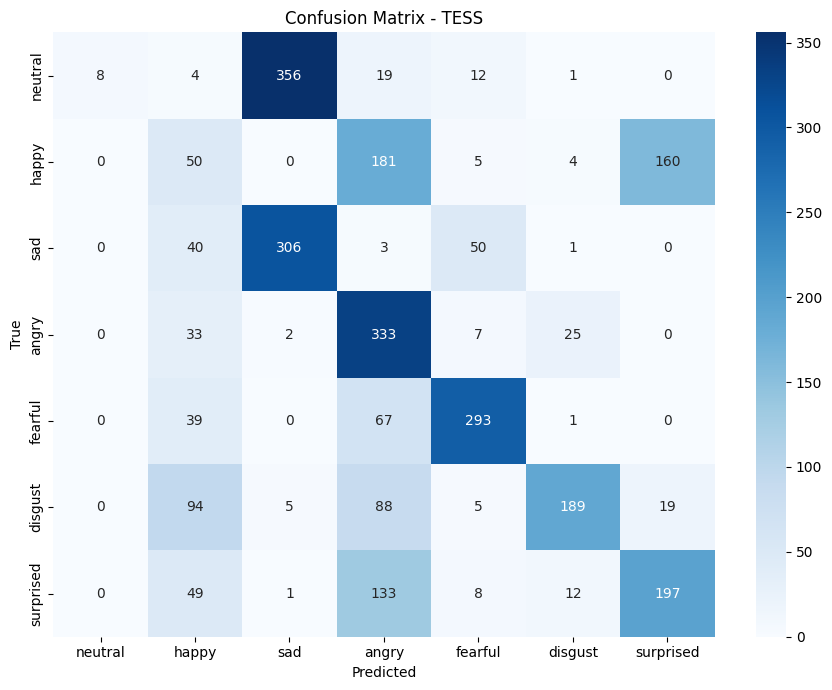

In [186]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

cm = confusion_matrix(y_tess, y_pred_tess)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - TESS')
plt.tight_layout()
plt.show()